In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pylab import mpl
# 设置中文显示字体
mpl.rcParams["font.sans-serif"] = ["SimHei"]
from fast_kurtogram import Fast_Kurtogram # 导入你提供的代码
from scipy import signal
from scipy.linalg import toeplitz
import os
import scipy.io as scio

快速谱峭度

In [104]:

# 1. 参数设置
fs = 64000              # 采样频率 20kHz
fault_freq = 9.7         # 模拟轴承故障频率 (如 BPFO = 80Hz)
# file_path=r'../数据集/cwru/1730_12k_0.014-Ball.mat'
def ar_prewhiten_demo(y, order=20):
    """简单的 AR 预白化实现"""
    # 1. 计算自相关
    r = np.correlate(y, y, mode='full')[len(y)-1 : len(y)+order]
    # 2. 求解 Yule-Walker 方程 (Toeplitz 矩阵)
    try:
        R = toeplitz(r[:-1])
        R += np.eye(order) * 1e-9 # 正则化防止奇异
        a = np.linalg.solve(R, -r[1:])
    except:
        return y # 失败则返回原信号
    
    ar_coeffs = np.concatenate(([1], a))
    # 3. 滤波得到残差
    residual = signal.lfilter(ar_coeffs, [1], y)
    return residual

def fast_kurtogram(data,fs):
    data = data.flatten()
    print("--- 开始预白化 ---")
    data = ar_prewhiten_demo(data, order=30) 
    print("--- 开始谱峭度自动检测 ---")
    # 4. 调用你提供的 Fast_Kurtogram 函数
    # nlevel=4 代表分解深度，通常 3-5 层足够
    Kwav, Level_w, freq_w, c, f_low, f_high = Fast_Kurtogram(
        data, nlevel=4, Fs=fs, verbose=False
    )
    print(f"检测完成！")
    print(f"自动锁定的共振频带: {f_low} Hz - {f_high} Hz")
    # 5. 对提取出的复包络 c 进行包络谱分析 (验证故障频率)
    # c 是滤波后的复信号包络
    envelope = np.abs(c)
    # 去除直流分量后做 FFT
    env_fft = np.abs(np.fft.rfft(envelope - np.mean(envelope)))
    env_freqs = np.fft.rfftfreq(len(envelope), 1/(fs / (len(data)/len(c))))
    
    return Kwav,env_fft, env_freqs



In [105]:
def plot_diagnosti(ax,env_fft,env_freqs,title):
    ax.plot(env_freqs, env_fft, color='#1f77b4', lw=1.2, label='包络幅值', zorder=3)
    # 4. 细节美化
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlim(0,200)
    ax.grid(True, linestyle=':', alpha=0.5)

    # # 动态调整 Y 轴 (避开低频噪声)
    # valid_idx = env_freqs > 1
    # if any(valid_idx):
    #     ax.set_ylim(0, np.max(env_fft[valid_idx]) * 1.8)

    ax.legend(loc='upper right', fontsize=8)


In [106]:
"""批量处理文件夹内的所有 CSV 文件"""
def process_folder(folder_path):
    files = sorted([f for f in os.listdir(folder_path) if f.endswith('.csv')])
    cols = 3
    rows = (len(files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows), constrained_layout=True)
    axes = axes.flatten()
    for i, file_name in enumerate(files):
        # 1. 自动从文件名解析频率 (假设格式为 ..._40Hz_...)
        motor_f = float(file_name.split('Hz')[0].split('_')[-1])
        df = pd.read_csv(os.path.join(folder_path, file_name),usecols=['CH17'])
        data = df.iloc[:, 0].values
        # 3. 计算与绘图
        Kwav,env_fft, env_freqs = fast_kurtogram(data,fs)
        plot_diagnosti(axes[i],env_fft,env_freqs,title=file_name)
        print(f"Processed: {file_name}")



--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 16000.0 Hz - 24000.0 Hz
Processed: data_leftaxlebox_M0_G0_LA2+LA3_RA0_20Hz_+10kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 12032.0 Hz - 14016.0 Hz
Processed: data_leftaxlebox_M0_G0_LA2+LA3_RA0_20Hz_-10kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 19968.0 Hz - 24000.0 Hz
Processed: data_leftaxlebox_M0_G0_LA2+LA3_RA0_20Hz_0kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 12032.0 Hz - 14016.0 Hz
Processed: data_leftaxlebox_M0_G0_LA2+LA3_RA0_40Hz_+10kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 12032.0 Hz - 16000.0 Hz
Processed: data_leftaxlebox_M0_G0_LA2+LA3_RA0_40Hz_-10kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 18688.0 Hz - 21312.0 Hz
Processed: data_leftaxlebox_M0_G0_LA2+LA3_RA0_40Hz_0kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 24000.0 Hz - 25984.0 Hz
Processed: data_leftaxlebox_M0_G0_LA2+LA3_RA0_60Hz_+10kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 17984.0 Hz - 1996

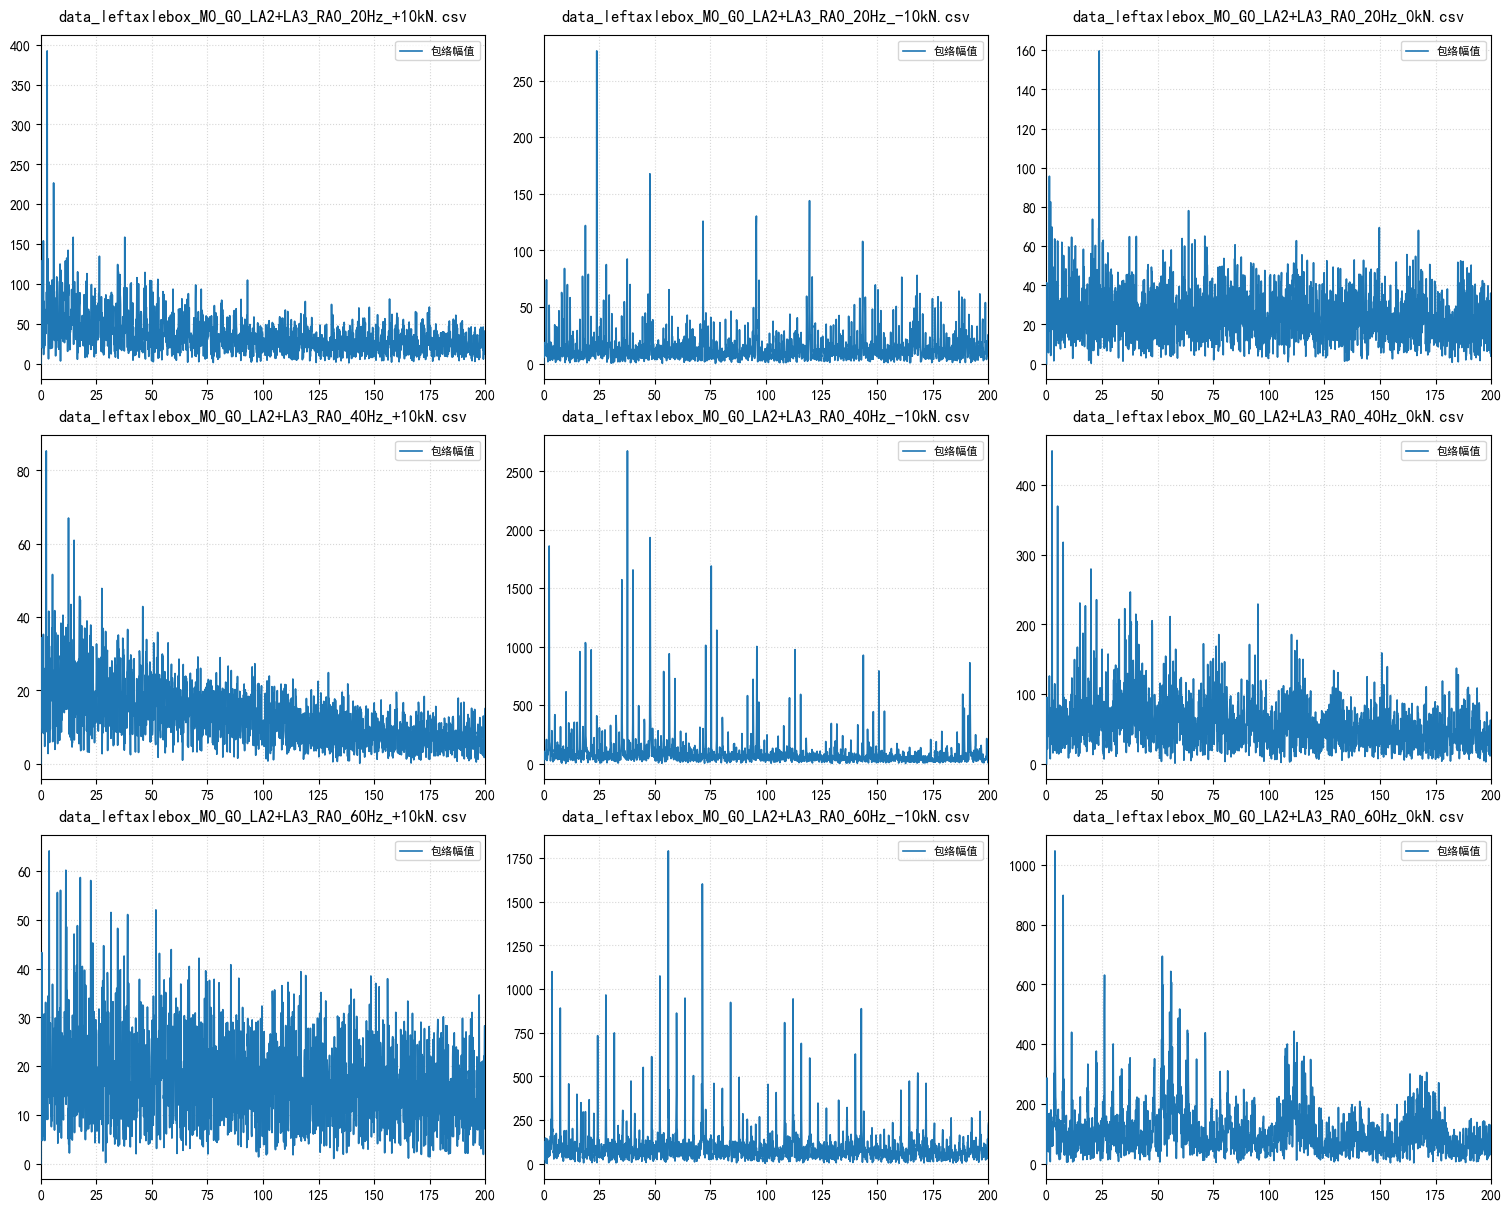

In [107]:

process_folder(folder_path='../数据集/BJTU/外圈加滚动体')

--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 13312.0 Hz - 16000.0 Hz
Processed: data_leftaxlebox_M0_G0_LA3_RA0_20Hz_+10kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 12032.0 Hz - 14016.0 Hz
Processed: data_leftaxlebox_M0_G0_LA3_RA0_20Hz_-10kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 12032.0 Hz - 14016.0 Hz
Processed: data_leftaxlebox_M0_G0_LA3_RA0_20Hz_0kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 25984.0 Hz - 28032.0 Hz
Processed: data_leftaxlebox_M0_G0_LA3_RA0_40Hz_+10kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 8000.0 Hz - 9984.0 Hz
Processed: data_leftaxlebox_M0_G0_LA3_RA0_40Hz_-10kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 24000.0 Hz - 25984.0 Hz
Processed: data_leftaxlebox_M0_G0_LA3_RA0_40Hz_0kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 24000.0 Hz - 26688.0 Hz
Processed: data_leftaxlebox_M0_G0_LA3_RA0_60Hz_+10kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 28032.0 Hz - 30016.0 Hz
Processed: data_leftaxl

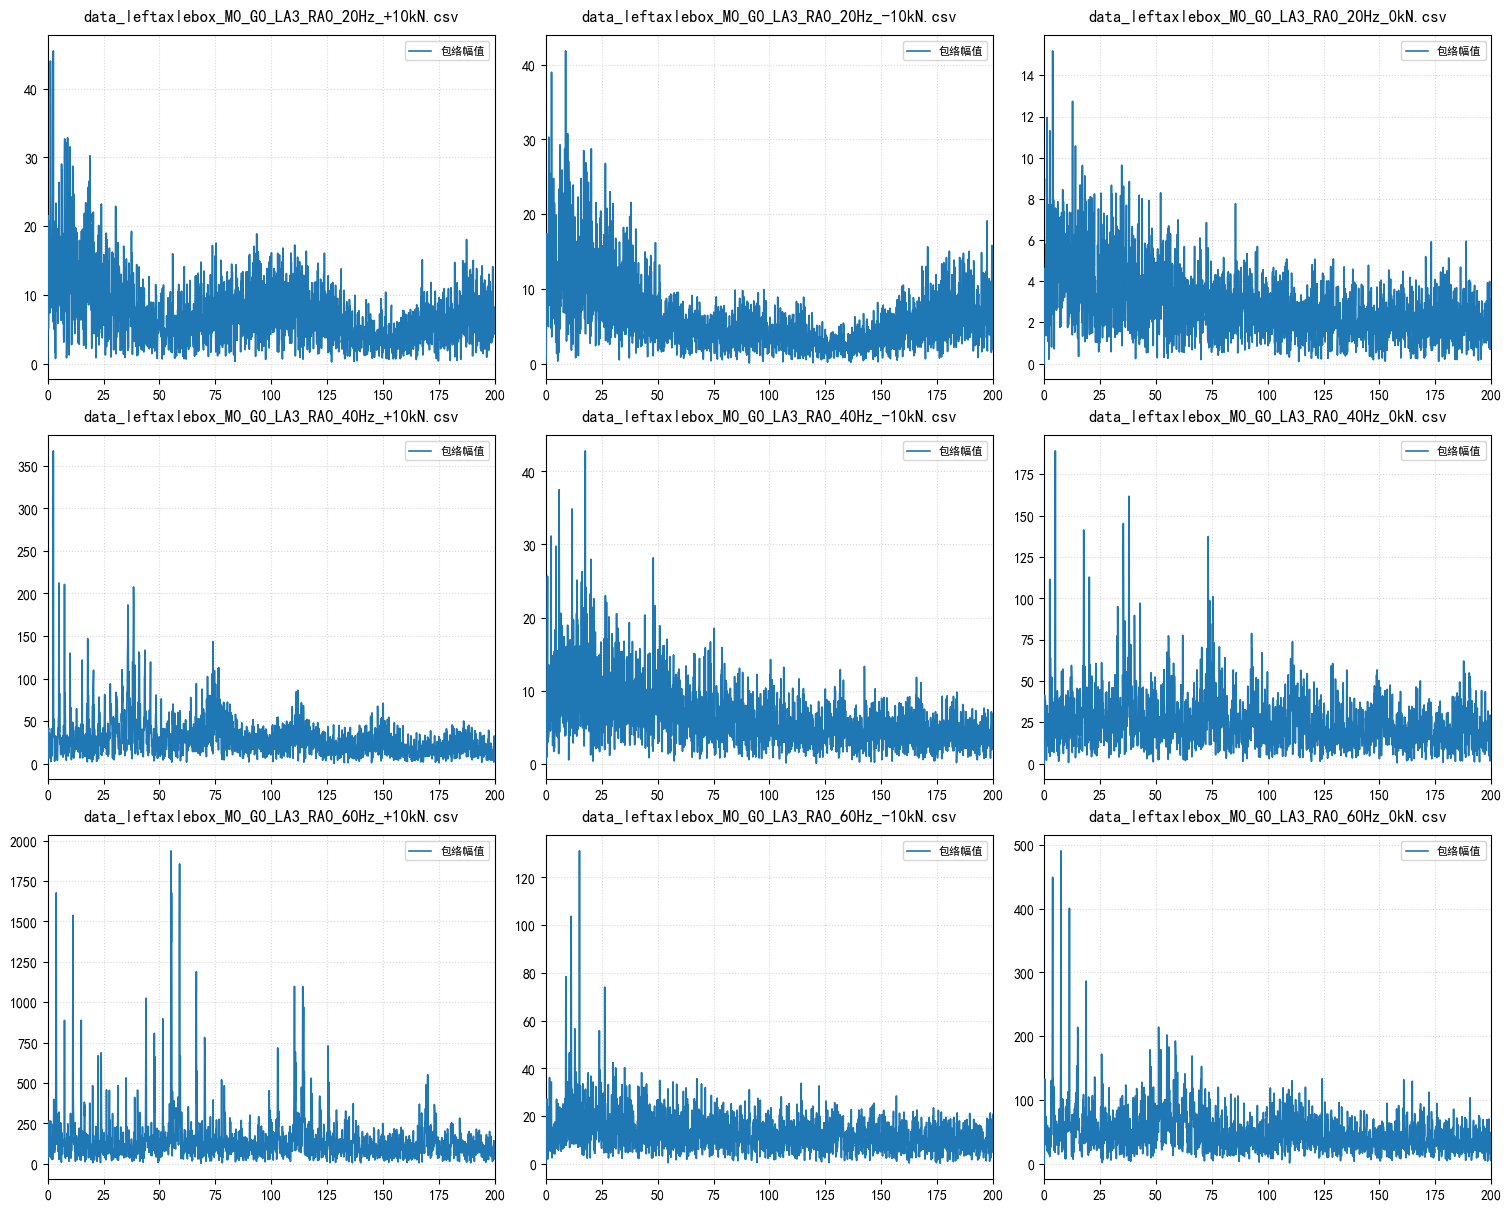

In [108]:
process_folder(folder_path='../数据集/BJTU/滚动体')

--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 24000.0 Hz - 25984.0 Hz
Processed: data_leftaxlebox_M0_G0_LA1_RA0_20Hz_+10kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 25984.0 Hz - 28032.0 Hz
Processed: data_leftaxlebox_M0_G0_LA1_RA0_20Hz_-10kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 19968.0 Hz - 22016.0 Hz
Processed: data_leftaxlebox_M0_G0_LA1_RA0_20Hz_0kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 16000.0 Hz - 18688.0 Hz
Processed: data_leftaxlebox_M0_G0_LA1_RA0_40Hz_+10kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 25984.0 Hz - 28032.0 Hz
Processed: data_leftaxlebox_M0_G0_LA1_RA0_40Hz_-10kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 16000.0 Hz - 18688.0 Hz
Processed: data_leftaxlebox_M0_G0_LA1_RA0_40Hz_0kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 16000.0 Hz - 19968.0 Hz
Processed: data_leftaxlebox_M0_G0_LA1_RA0_60Hz_+10kN.csv
--- 开始预白化 ---
--- 开始谱峭度自动检测 ---
检测完成！
自动锁定的共振频带: 17984.0 Hz - 19968.0 Hz
Processed: data_lefta

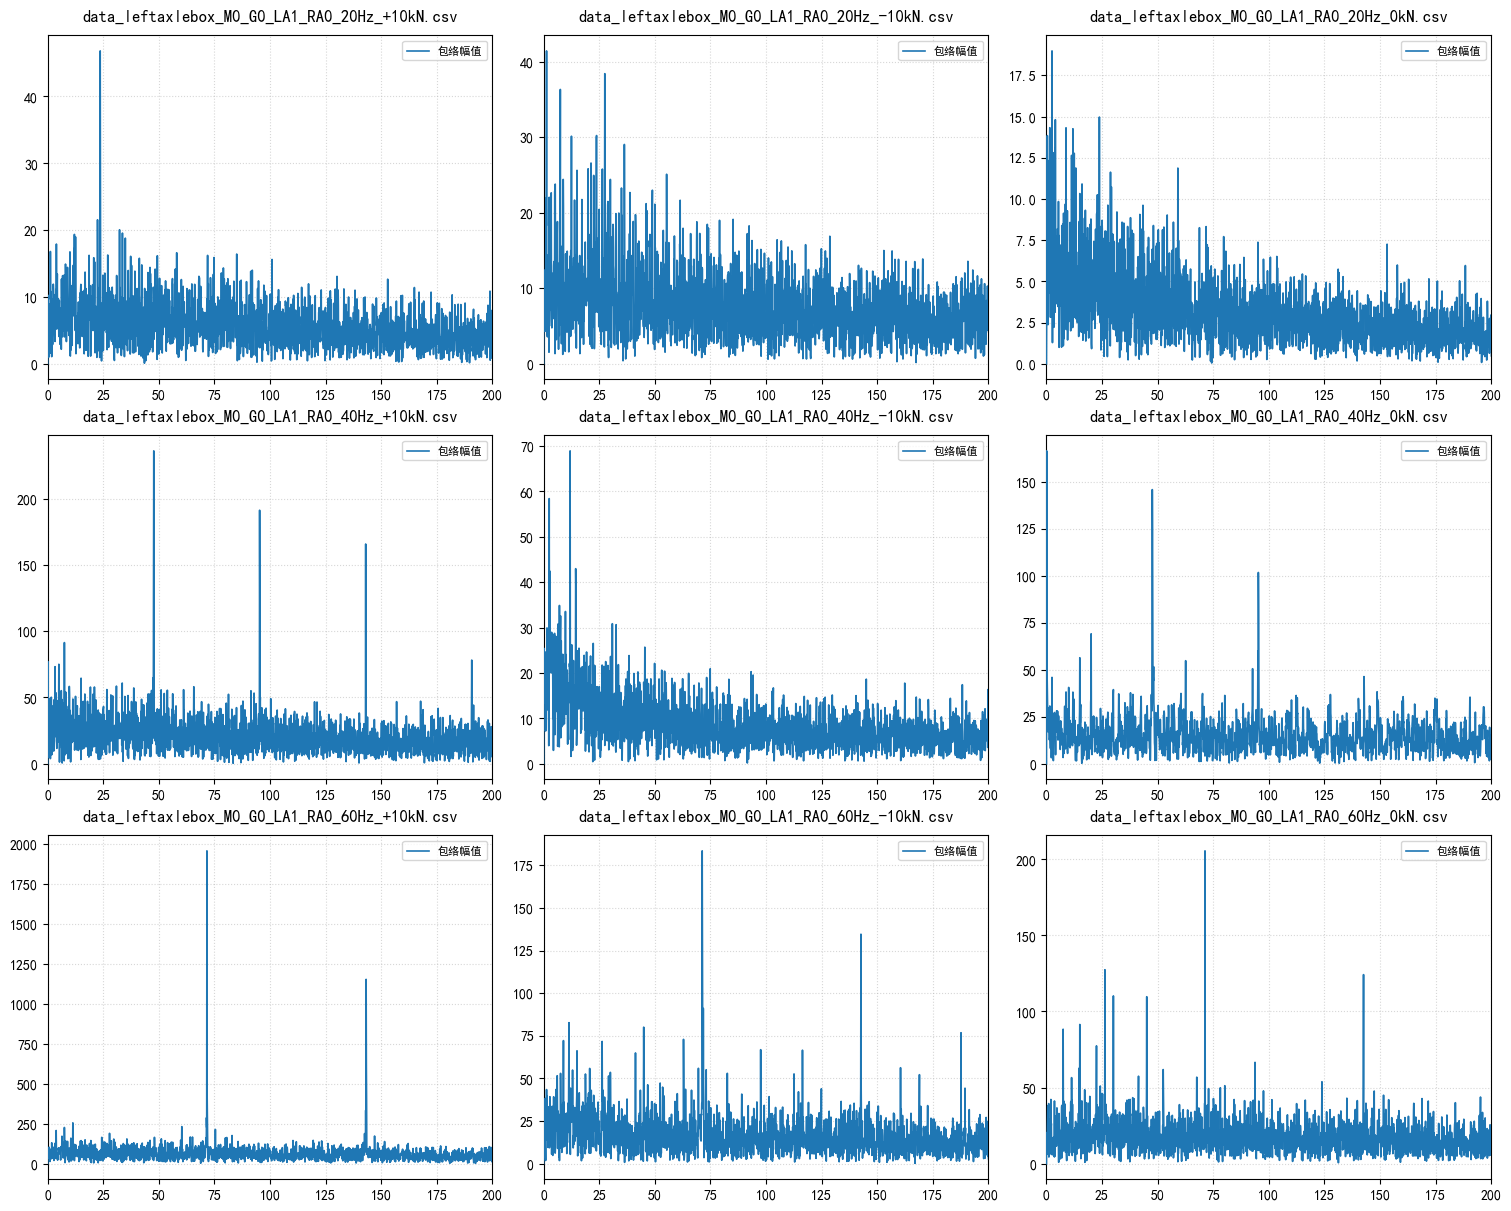

In [109]:
process_folder(folder_path='../数据集/BJTU/内圈')

#问题
1.代码运行极慢
2.实际处理效果甚至不如传统的包络解析